# Proyecto de Análisis de Datos: Evolución Global del COVID-19
**Autor:** StalkerData  
**Dataset:** Our World in Data (OWID)

### Introducción
En este notebook realizaremos un análisis exploratorio de los datos de la pandemia de COVID-19. El objetivo es limpiar la información, transformar variables para hacer comparaciones justas entre países y visualizar las tendencias de contagios y muertes a nivel mundial.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
import requests

# Configuración para que el notebook sea más legible
warnings.filterwarnings("ignore")

# Creamos carpetas para organizar el proyecto
os.makedirs("../data", exist_ok=True)
os.makedirs("../results", exist_ok=True)

## 1. Comprensión del Dataset
El primer paso es obtener los datos actualizados desde el repositorio oficial de *Our World in Data* y realizar una carga selectiva de las columnas que nos interesan para el análisis.

In [2]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
response = requests.get(url)

if response.status_code == 200:
    with open("../data/owid-covid-data.csv", "wb") as f:
        f.write(response.content)
    print("✅ Archivo descargado correctamente.")
else:
    print(f"❌ Error en la descarga. Código: {response.status_code}")

✅ Archivo descargado correctamente.


In [3]:
# Cargamos solo las columnas necesarias para ahorrar memoria
df = pd.read_csv(
    "../data/owid-covid-data.csv",
    usecols=[
        "location",
        "date",
        "total_cases",
        "new_cases",
        "total_deaths",
        "population",
    ],
    parse_dates=["date"],  # Convertimos la fecha directamente al cargar
)

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (429435, 6)


,location,date,total_cases,new_cases,total_deaths,population
0,Afghanistan,2020-01-05,0.0,0.0,0.0,41128772
1,Afghanistan,2020-01-06,0.0,0.0,0.0,41128772
2,Afghanistan,2020-01-07,0.0,0.0,0.0,41128772
3,Afghanistan,2020-01-08,0.0,0.0,0.0,41128772
4,Afghanistan,2020-01-09,0.0,0.0,0.0,41128772


## 2. Limpieza de Datos
En esta sección identificaremos valores nulos y decidiremos cómo tratarlos. En los datos de COVID, los valores faltantes en casos acumulados suelen significar que no hubo cambios respecto al día anterior o que no se reportaron datos.

In [4]:
# Revisión de valores faltantes
print("Valores nulos detectados:")
print(df.isnull().sum())

Valores nulos detectados:
location            0
date                0
total_cases     17631
new_cases       19276
total_deaths    17631
population          0
dtype: int64


In [5]:
df_clean = df.copy()

# Para los totales, rellenamos hacia adelante (el valor de hoy es al menos el de ayer)
df_clean["total_cases"] = df_clean.groupby("location")["total_cases"].ffill().fillna(0)
df_clean["total_deaths"] = (
    df_clean.groupby("location")["total_deaths"].ffill().fillna(0)
)

# Para casos nuevos, si es nulo asumimos que es 0
df_clean["new_cases"] = df_clean["new_cases"].fillna(0)

print("Limpieza completada. Nulos restantes:")
print(df_clean.isnull().sum())

Limpieza completada. Nulos restantes:
location        0
date            0
total_cases     0
new_cases       0
total_deaths    0
population      0
dtype: int64


## 3. Transformación de Datos y Filtrado
El dataset original incluye agregados por continentes y niveles de ingreso (ej. "World", "Europe"). Para un análisis por país, debemos separar estos registros. Además, crearemos métricas **por millón de habitantes** para poder comparar países de distintos tamaños de forma justa.

In [6]:
# Lista de etiquetas que no son países individuales
no_son_paises = [
    "World",
    "High income",
    "Upper middle income",
    "Europe",
    "Asia",
    "North America",
    "South America",
    "Lower middle income",
    "European Union",
    "Africa",
    "Low income",
    "Oceania",
]

# Creamos dos DataFrames distintos
df_paises = df_clean[~df_clean["location"].isin(no_son_paises)].copy()
df_regiones = df_clean[df_clean["location"].isin(no_son_paises)].copy()

print(f"Registros de países: {df_paises.shape[0]}")

Registros de países: 417680


In [7]:
# Calculamos métricas relativas a la población
df_paises["total_cases_per_million"] = (
    df_paises["total_cases"] / df_paises["population"]
) * 1_000_000
df_paises["total_deaths_per_million"] = (
    df_paises["total_deaths"] / df_paises["population"]
) * 1_000_000
df_paises["fatality_rate"] = (
    df_paises["total_deaths"] / df_paises["total_cases"]
) * 100

df_paises.head()

,location,date,total_cases,new_cases,total_deaths,population,total_cases_per_million,total_deaths_per_million,fatality_rate
0,Afghanistan,2020-01-05,0.0,0.0,0.0,41128772,0.0,0.0,NaN
1,Afghanistan,2020-01-06,0.0,0.0,0.0,41128772,0.0,0.0,NaN
2,Afghanistan,2020-01-07,0.0,0.0,0.0,41128772,0.0,0.0,NaN
3,Afghanistan,2020-01-08,0.0,0.0,0.0,41128772,0.0,0.0,NaN
4,Afghanistan,2020-01-09,0.0,0.0,0.0,41128772,0.0,0.0,NaN


## 4. Análisis por País
A continuación, identificamos los países con mayor impacto en términos de contagios y mortalidad, así como aquellos que presentan una menor tasa de letalidad.

In [8]:
# Obtenemos el último dato registrado para cada país
top_case = (
    df_paises.groupby("location")["total_cases_per_million"]
    .last()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_deaths = (
    df_paises.groupby("location")["total_deaths_per_million"]
    .last()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Países con más casos por millón:")
display(top_case)

Top 10 Países con más casos por millón:


,location,total_cases_per_million
0,Cyprus,777237.231406
1,Brunei,774435.303184
2,San Marino,750727.218759
3,Austria,680392.012320
4,South Korea,667207.061598
5,Faroe Islands,652484.138788
6,Slovenia,639944.561932
7,Gibraltar,628882.700370
8,Martinique,626793.138727
9,Luxembourg,607692.082007


## 5. Visualización de Resultados
Para entender la evolución de la pandemia, generaremos gráficos de líneas para las tendencias temporales y gráficos de barras para las comparaciones entre países.

In [9]:
def crearGraficaLineas(x, y, titulo, etiquetaX, etiquetaY, nombre_archivo):
    plt.figure(figsize=(12, 5))
    plt.plot(x, y / 1_000_000, color="tab:blue", linewidth=2)
    plt.title(titulo, fontsize=14)
    plt.xlabel(etiquetaX)
    plt.ylabel(etiquetaY)
    plt.grid(True, linestyle="--", alpha=0.6)

    path = f"../results/{nombre_archivo}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()


def crearGraficaBarras(x, y, titulo, etiquetaX, etiquetaY, nombre_archivo):
    plt.figure(figsize=(12, 5))
    plt.bar(x, y, color="skyblue", edgecolor="navy")
    plt.title(titulo, fontsize=14)
    plt.xlabel(etiquetaX)
    plt.ylabel(etiquetaY)
    plt.xticks(rotation=45)

    path = f"../results/{nombre_archivo}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()

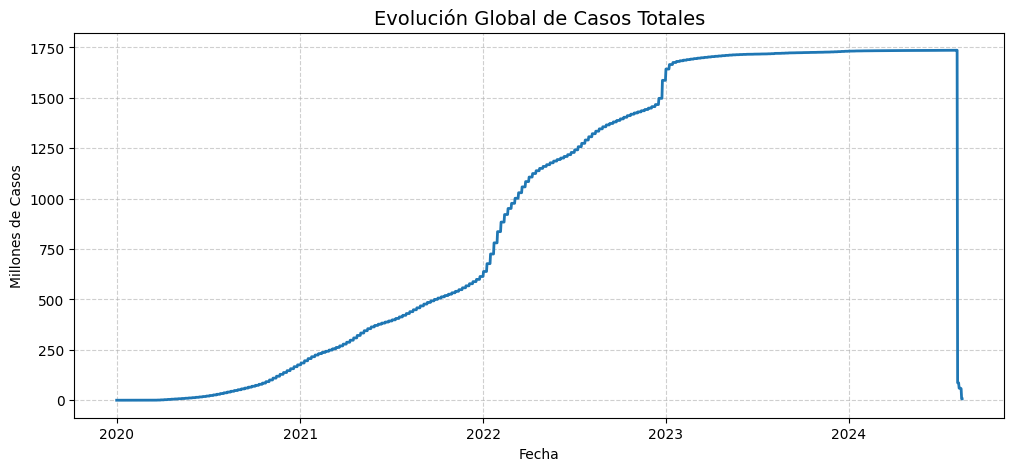

In [10]:
# Evolución temporal global
evol_temporal = df_paises.groupby("date")["total_cases"].sum().reset_index()

crearGraficaLineas(
    evol_temporal["date"],
    evol_temporal["total_cases"],
    "Evolución Global de Casos Totales",
    "Fecha",
    "Millones de Casos",
    "evolucion_casos",
)

**📝 Análisis de la Evolución Global**  
Al observar la gráfica de **Casos Totales**, podemos extraer las siguientes conclusiones clave:

* **Crecimiento Constante:** Desde el inicio de 2020 hasta finales de 2021, la pandemia mantuvo un crecimiento sostenido. Sin embargo, a principios de **2022**, se observa un incremento mucho más acelerado (una curva más empinada), lo que coincide con la propagación de variantes más contagiosas a nivel mundial.
* **Estabilización:** A partir de 2023, la pendiente de la curva empieza a suavizarse. Esto indica que, aunque se seguían sumando casos, el ritmo de nuevos contagios disminuyó considerablemente en comparación con los años anteriores.
* **Nota sobre el final de la gráfica:** Se observa una caída brusca al final de la línea (cerca de 2024). Es importante aclarar que esto **no significa que los casos desaparecieron**, sino que es una **anomalía en los datos** (probablemente el dataset dejó de actualizarse o los países dejaron de reportar de forma diaria en esa fecha).

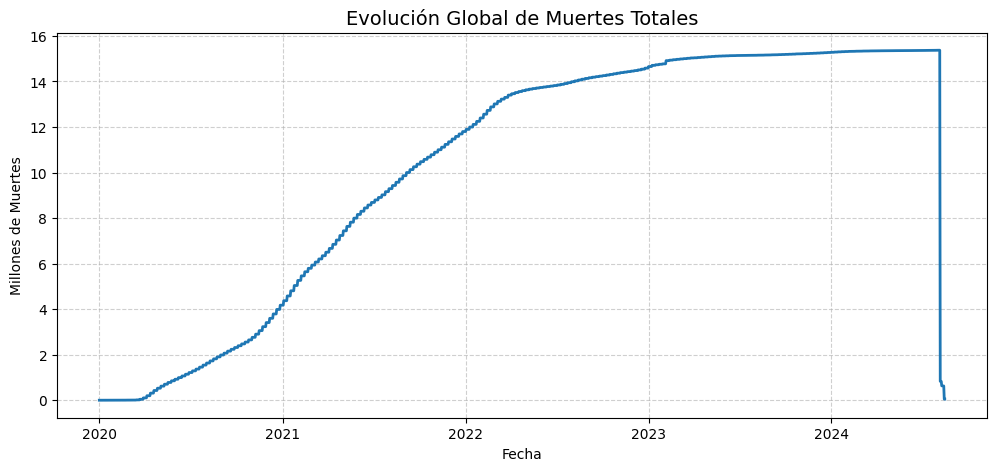

In [11]:
# Evolución temporal global de muertes
evol_temporal_muertes = df_paises.groupby("date")["total_deaths"].sum().reset_index()

crearGraficaLineas(
    evol_temporal_muertes["date"],
    evol_temporal_muertes["total_deaths"],
    "Evolución Global de Muertes Totales",
    "Fecha",
    "Millones de Muertes",
    "evolucion_muertes",
)

**📝 Análisis de la Evolución de Muertes Totales**  
Al analizar la curva acumulada de fallecimientos, podemos observar comportamientos distintos a la de contagios:

* **Periodo de Mayor Impacto:** A diferencia de los casos (que tuvieron su mayor salto en 2022), la pendiente más pronunciada en las muertes se observa durante **2021**. Esto sugiere que, aunque hubo menos contagios que en olas posteriores, la severidad del virus antes de la vacunación masiva fue mucho mayor.
* **Efecto de la Inmunización y Tratamientos:** A partir de mediados de **2022**, la curva comienza a aplanarse de forma notable (un "plateau"). Esto indica que, a pesar de que los contagios seguían ocurriendo (como vimos en la gráfica anterior), la cantidad de personas que fallecían por el virus disminuyó drásticamente.
* **Anomalía Final:** Nuevamente, se observa una caída vertical al final de la serie en 2024. Como analistas, determinamos que este descenso es un **error de reporte o cese de actualizaciones** en el dataset, ya que una cifra acumulada de muertes nunca puede disminuir.

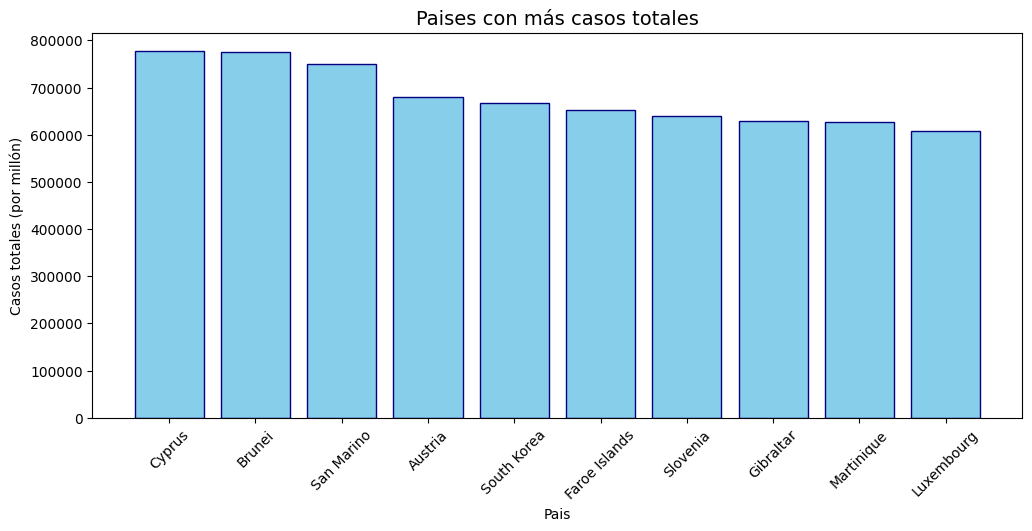

In [12]:
# Países con más casos totales
crearGraficaBarras(
    top_case["location"],
    top_case["total_cases_per_million"],
    "Paises con más casos totales",
    "Pais",
    "Casos totales (por millón)",
    "Paises_mas_casos",
)

**📝 Análisis de Casos por Millón de Habitantes**  
Al observar los países con mayor incidencia de contagios, destaca un hallazgo clave gracias a la **normalización de los datos**:

* **Impacto en Países Pequeños:** Los países que lideran la lista no son los más poblados (como EE. UU. o India), sino naciones con poblaciones más pequeñas como **Chipre, San Marino y Brunéi**. Esto ocurre porque, al calcular los casos **por cada millón de personas**, podemos ver la verdadera penetración del virus en la sociedad, independientemente del tamaño del país.
* **Alta Tasa de Contagio:** En los países del "Top 3", la cifra supera los 700,000 casos por millón. Esto sugiere que, estadísticamente, cerca del **70% de su población** fue registrada como contagiada en algún momento de la pandemia.
* **Diversidad Geográfica:** El virus afectó de manera masiva a regiones muy distintas, desde Europa (Austria, Eslovenia) hasta Asia (Corea del Sur, Brunéi), demostrando que la alta incidencia no estuvo limitada a un solo continente.

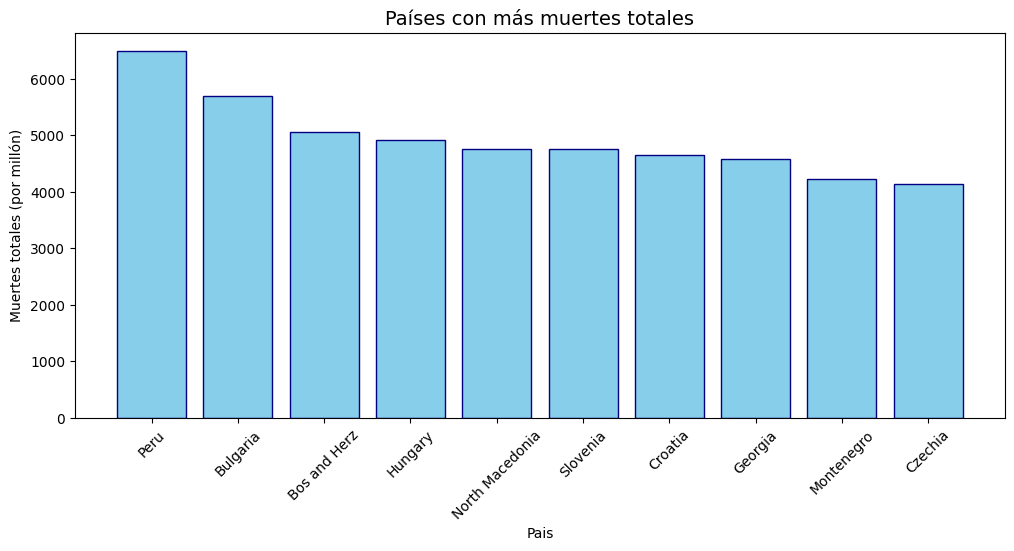

In [13]:
# Países con más muertes totales
top_deaths["location"] = top_deaths["location"].replace(
    "Bosnia and Herzegovina", "Bos and Herz"
)

crearGraficaBarras(
    top_deaths["location"],
    top_deaths["total_deaths_per_million"],
    "Países con más muertes totales",
    "Pais",
    "Muertes totales (por millón)",
    "Paises_mas_muertes",
)

**📝 Análisis de Mortalidad por Millón de Habitantes**  
Al analizar las muertes normalizadas por población, los resultados cambian drásticamente respecto a la gráfica de contagios, revelando datos muy importantes:

* **El Caso Crítico de Perú:** Perú destaca notablemente como el país con la mayor tasa de mortalidad en el mundo, superando las **6,000 muertes por cada millón de habitantes**. Este dato es un indicador de que, en este país, la pandemia tuvo un impacto mucho más letal que en cualquier otra nación, posiblemente debido a factores como la saturación del sistema de salud.
* **Concentración en Europa del Este:** Es evidente una fuerte presencia de países de Europa del Este y los Balcanes en este "Top 10" (Bulgaria, Hungría, Bosnia y Herzegovina, Macedonia del Norte, entre otros). Esto sugiere que esta región fue una de las más golpeadas en términos de severidad clínica durante la pandemia.
* **Contraste entre Contagios y Muertes:** Es fundamental notar que los países que lideraban la gráfica de **más casos** (como Chipre o Brunéi) no aparecen en esta lista de **más muertes**. Esto demuestra que tener muchos contagios no siempre se traduce en muchas muertes; la mortalidad depende de otros factores como la edad de la población, la capacidad hospitalaria y la cobertura de vacunación.

## 7. Conclusiones e Interpretación Final

Tras completar el análisis del dataset global de COVID-19, hemos llegado a las siguientes conclusiones clave divididas en hallazgos estadísticos y aprendizajes técnicos:

### 📊 Hallazgos Principales
1. **La importancia de la Normalización:** Si hubiéramos analizado solo números absolutos, países grandes como EE. UU. o India siempre estarían en el primer lugar. Al usar la métrica **"por millón de habitantes"**, descubrimos que el impacto real fue mucho más severo en naciones pequeñas como **Chipre** (en contagios) y **Perú** (en mortalidad).
2. **Desconexión entre Contagios y Muertes:** El análisis revela que una alta tasa de contagios no siempre implica una alta tasa de mortalidad. Países como Corea del Sur o Brunéi manejaron volúmenes de casos muy altos con una mortalidad controlada, mientras que otros países, especialmente en **Europa del Este y Sudamérica (Perú)**, enfrentaron una letalidad mucho más agresiva.
3. **Evolución de la Pandemia:** Las gráficas temporales muestran que el año **2022** fue el de mayor propagación del virus, pero **2021** fue el más crítico en términos de vidas perdidas. Esto sugiere que factores como la vacunación masiva y la evolución de las variantes cambiaron la dinámica de la pandemia con el tiempo.

### 🛠️ Reflexión Técnica
* **Calidad de Datos:** Identificamos que los datasets del mundo real no son perfectos. La caída drástica en las gráficas al final de 2024 nos recordó la importancia de cuestionar los datos y entender que los reportes pueden cesar o contener errores.
* **Procesamiento:** El uso de técnicas como `ffill()` (relleno hacia adelante) fue fundamental para tratar los valores nulos en datos acumulados, asegurando que las curvas de tendencia no tuvieran saltos artificiales hacia cero.